# TASK 1

## LIBRARIES

In [215]:
import random
import heapq
import itertools
import numpy as np
from scipy.interpolate import interp1d
from typing import List
import matplotlib.pyplot as plt
from scipy import stats

## CLASSES

### TASK

In [216]:
class Task:
    def __init__(self, arrival_time: float, task_type: str, L: float, C: float, D_max: float):
        self.arrival_time = arrival_time
        self.task_type = task_type
        self.L = L
        self.C = C
        self.D_max = D_max

### MEASURE

In [217]:
class Measure:
    def __init__(self):
        # Dati discreti
        self.processed_tasks = 0
        self.cumulative_delay = 0.0
        self.qos_met = 0
        self.delay_list = []
        
        # Dati continui (Aree per l'integrale)
        self.area_queue = 0.0
        self.area_server_busy = 0.0
        self.last_update_time = 0.0

    def update_time_averages(self, current_time: float, queue_length: int, is_busy: bool) -> None:
        time_delta = current_time - self.last_update_time
        if time_delta > 0:
            self.area_queue += time_delta * queue_length
            self.area_server_busy += time_delta * (1 if is_busy else 0)
        self.last_update_time = current_time

    def record_task_completion(self, delay: float, d_max: float) -> None:
        self.processed_tasks += 1
        self.cumulative_delay += delay
        self.delay_list.append(delay)
        if delay <= d_max:
            self.qos_met += 1

    def reset_statistics(self, current_time: float) -> None:
        self.processed_tasks = 0
        self.cumulative_delay = 0.0
        self.qos_met = 0
        self.delay_list.clear()
        
        self.area_queue = 0.0
        self.area_server_busy = 0.0
        self.last_update_time = current_time

    @property
    def average_delay(self) -> float:
        return self.cumulative_delay / self.processed_tasks if self.processed_tasks > 0 else 0.0

### SENSING NODE

In [218]:
class SensingNode:
    def __init__(self, node_id: int, f_loc: float, lambda_rate: float):
        self.node_id = node_id
        self.f_loc = f_loc
        self.lambda_rate = lambda_rate
        
        self.queue = []
        self.server_busy = False
        self.stats = Measure()

## HAPS

In [219]:
class HapsNode:
    def __init__(self, f_loc: float, lambda_rate: float):
        self.f_loc = f_loc
        self.lambda_rate = lambda_rate
        self.queue = []
        self.server_busy = False
        self.stats = Measure()

## FUNCTIONS

### TASK GENERATION

In [220]:
def task_generation(time, FES, node, alpha, params_Ks, params_Kt, event_counter):
    # 1. Arrivi Esponenziali (Era già corretto!)
    inter_arrival = random.expovariate(node.lambda_rate)
    heapq.heappush(FES, (time + inter_arrival, next(event_counter), 'task_generation', node, alpha, params_Ks, params_Kt, event_counter))
    
    # Generazione Task
    if random.random() <= alpha:
        task = Task(time, "K_s", params_Ks['L'], params_Ks['C'], params_Ks['D_max'])
    else:
        task = Task(time, "K_t", params_Kt['L'], params_Kt['C'], params_Kt['D_max'])
        
    node.stats.update_time_averages(time, len(node.queue), 1 if node.server_busy else 0)
    
    if not node.server_busy:
        node.server_busy = True
        
        # LA MODIFICA M/M/1: Il servizio ora è esponenziale!
        actual_C = random.expovariate(1.0 / task.C)
        T_s = actual_C / node.f_loc
        
        heapq.heappush(FES, (time + T_s, next(event_counter), 'local_departure', node, task, event_counter))
    else:
        node.queue.append(task)



### LOCAL DEPARTURE

In [221]:
def local_departure(time, FES, node, task, event_counter):
    node.stats.update_time_averages(time, len(node.queue), 1 if node.server_busy else 0)
    
    delay = time - task.arrival_time
    node.stats.record_task_completion(delay, task.D_max)
    
    if len(node.queue) > 0:
        next_task = node.queue.pop(0)
        
        # LA MODIFICA M/M/1 anche qui
        actual_C = random.expovariate(1.0 / next_task.C)
        T_s = actual_C / node.f_loc
        
        heapq.heappush(FES, (time + T_s, next(event_counter), 'local_departure', node, next_task, event_counter))
    else:
        node.server_busy = False

### RUN SIM MODE

In [222]:
def run_sim_node(tasks_to_complete, lambda_rate, f_loc, params_Ks, params_Kt=None, alpha=1.0, seed=42):
    random.seed(seed)
    event_counter = itertools.count() 
    FES = []
    
    node = SensingNode(node_id=1, f_loc=f_loc, lambda_rate=lambda_rate)
    
    # Innesco del sistema a vuoto
    heapq.heappush(FES, (0.0, next(event_counter), 'task_generation', node, alpha, params_Ks, params_Kt, event_counter))
    
    time_points = [0.0]
    queue_lengths = [0]
    server_status = [0.0] 
    
    current_time = 0.0
    
    while len(node.stats.delay_list) < tasks_to_complete and len(FES) > 0:
        event_time, _, event_type, *args = heapq.heappop(FES)
        current_time = event_time
        
        if event_type == 'task_generation':
            task_generation(current_time, FES, args[0], args[1], args[2], args[3], args[4])
        elif event_type == 'local_departure':
            local_departure(current_time, FES, args[0], args[1], args[2])
            
        time_points.append(current_time)
        queue_lengths.append(len(node.queue))
        server_status.append(1.0 if node.server_busy else 0.0)
        
    return node.stats.delay_list, time_points, queue_lengths, server_status

### RUN MULTIPLE SIMS

In [223]:
def run_multiple_sims(num_runs, tasks_to_complete, time_limit, lambda_rate, f_loc, params_Ks, params_Kt=None, alpha=1.0):
    all_delays = np.zeros((num_runs, tasks_to_complete))
    
    # Griglia temporale fissa per le metriche continue (10 campioni/s)
    num_samples = int(time_limit * 10) 
    time_grid = np.linspace(0, time_limit, num_samples)
    
    sum_queues = np.zeros(num_samples)
    sum_utils = np.zeros(num_samples)
    
    for i in range(num_runs):
        delays, t_pts, q_lens, s_stats = run_sim_node(
            tasks_to_complete=tasks_to_complete, 
            lambda_rate=lambda_rate, 
            f_loc=f_loc, 
            params_Ks=params_Ks, 
            params_Kt=params_Kt, 
            alpha=alpha, 
            seed=(42+i)
        )
        
        all_delays[i, :] = delays[:tasks_to_complete]
        
        # Interpolazione a gradini
        f_q = interp1d(t_pts, q_lens, kind='previous', fill_value="extrapolate")
        f_s = interp1d(t_pts, s_stats, kind='previous', fill_value="extrapolate")
        
        sum_queues += f_q(time_grid)
        sum_utils += f_s(time_grid)
        
    # Calcolo delle Ensemble Averages
    avg_queue = sum_queues / num_runs
    avg_utilization = sum_utils / num_runs
    avg_delay = np.mean(all_delays, axis=0) 
    
    return time_grid, avg_queue, avg_utilization, avg_delay, all_delays

### PLOT AVG DELAY

In [224]:
def plot_avg_delay(avg_delay, lambda_rate, mu_rate, zoom_tasks=None):
    plt.figure(figsize=(10, 4))
    task_indices = range(1, len(avg_delay) + 1)
    
    plt.plot(task_indices, avg_delay, color='red', linewidth=1.5, label='Evoluzione Transitorio')
    
    media_effettiva = np.mean(avg_delay)
    plt.axhline(y=media_effettiva, color='orange', linestyle='-.', linewidth=2, 
                label=f'Media Globale ({media_effettiva:.3f} s)')
    
    if lambda_rate < mu_rate:
        # FORMULA M/M/1 Ripristinata
        delay_teorico = 1.0 / (mu_rate - lambda_rate)
        plt.axhline(y=delay_teorico, color='black', linestyle='--', 
                    label=f'Teorico a Regime ({delay_teorico:.3f} s)')
        
    plt.title("Ritardo Medio per Task (M/M/1)")
    plt.xlabel("Indice Task")
    plt.ylabel("Ritardo Medio [s]")
    if zoom_tasks is not None:
        plt.xlim(0, zoom_tasks)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### PLOT AVG QUEUE

In [225]:
def plot_avg_queue(time_grid, avg_queue, lambda_rate, mu_rate, zoom_time=None):
    plt.figure(figsize=(10, 4))
    plt.plot(time_grid, avg_queue, color='blue', linewidth=1.5, label='Evoluzione Transitorio')
    
    media_effettiva = np.mean(avg_queue)
    plt.axhline(y=media_effettiva, color='orange', linestyle='-.', linewidth=2, 
                label=f'Media Globale ({media_effettiva:.2f} task)')
    
    if lambda_rate < mu_rate:
        # FORMULA M/M/1 Ripristinata
        
        queue_teorica = lambda_rate**2 / (mu_rate * (mu_rate - lambda_rate))
        plt.axhline(y=queue_teorica, color='black', linestyle='--', 
                    label=f'Teorico a Regime ({queue_teorica:.2f} task)')

    plt.title("Evoluzione nel Tempo dei Task nel Sistema (M/M/1)")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Numero Medio di Task")
    if zoom_time is not None:
        plt.xlim(0, zoom_time)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### PLOT AVG UTILIZATION

In [226]:
def plot_avg_utilization(time_grid, avg_utilization, lambda_rate, mu_rate, zoom_time=None):
    plt.figure(figsize=(10, 4))
    
    plt.plot(time_grid, avg_utilization, color='green', linewidth=1.5, label='Evoluzione Transitorio')
    
    media_effettiva = np.mean(avg_utilization)
    plt.axhline(y=media_effettiva, color='orange', linestyle='-.', linewidth=2, 
                label=f'Media Globale ({media_effettiva:.2f})')
    
    rho_teorico = (lambda_rate / mu_rate)
    plt.axhline(y=rho_teorico, color='black', linestyle='--', 
                label=f'rho Teorico ({rho_teorico/(1-rho_teorico):.2f})')
    
    plt.title("Utilizzo Medio del Server")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Probabilità Server Occupato")
    
    # Impostiamo i limiti Y di base, ma li manteniamo compatibili con lo zoom
    plt.ylim(-0.05, 1.05) 
    
    # --- ZOOM ---
    if zoom_time is not None:
        plt.xlim(0, zoom_time)
        
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### ANALYZE WARMUP

In [227]:
def analyze_warmup(ensemble_delays, max_discard_percent=0.60, k_star=300):
    n = len(ensemble_delays)
    
    # Calcolo della media globale (per il calcolo della variazione relativa)
    x_bar = np.mean(ensemble_delays)
    
    # LA TUA NUOVA LINEA: Media a regime escludendo i primi k_star task
    x_bar_k_star = np.mean(ensemble_delays[k_star:])
    
    max_k = int(n * max_discard_percent)
    k_values = np.arange(1, max_k + 1)
    
    x_bar_k_list = []
    R_k_list = []
    
    for k in k_values:
        x_bar_k = np.mean(ensemble_delays[k:])
        x_bar_k_list.append(x_bar_k)
        R_k = (x_bar_k - x_bar) / x_bar
        R_k_list.append(R_k)
        
    # --- 1° GRAFICO: Media Troncata ---
    plt.figure(figsize=(10, 5))
    plt.plot(k_values, x_bar_k_list, color='purple', linewidth=2, label='Media Troncata ($\\bar{X}_k$)')
    
    # Tracciamo SOLO la linea orizzontale a regime (scartando i primi 300)
    plt.axhline(y=x_bar_k_star, color='green', linestyle='--', linewidth=2, 
                label=f'Media a regime ($\\bar{{X}}_{{{k_star}}}$) = {x_bar_k_star:.3f} s')
    
    plt.title(f"Media Troncata (scarto massimo {max_discard_percent*100:.0f}%)", fontsize=14)
    plt.xlabel("Numero di campioni scartati ($k$)", fontsize=12)
    plt.ylabel("Media Troncata [s]", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- 2° GRAFICO: Variazione Relativa ---
    plt.figure(figsize=(10, 5))
    plt.plot(k_values, R_k_list, color='darkorange', linewidth=2)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Riferimento Zero') 
    plt.title(f"Variazione Relativa rispetto alla media globale", fontsize=14)
    plt.xlabel("Numero di campioni scartati ($k$)", fontsize=12)
    plt.ylabel("Variazione Relativa ($R_k$)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()




### PERFORM STATISTICAL ANALYSIS

In [228]:
def perform_statistical_analysis(all_delays, k_star=75, confidence=0.95):
    """
    all_delays: Matrice 50 righe x 20.000 colonne (risultato di run_multiple_sims)
    k_star: Il numero di task da scartare per il warm-up
    """
    
    # 1. Pulizia: rimuoviamo il transitorio da ogni singola replica
    # Trasformiamo in array per usare lo slicing (righe=run, colonne=task)
    data = np.array(all_delays)
    trimmed_data = data[:, k_star:] 
    
    # 2. Otteniamo la stima della media per ogni singola replica (Ensemble)
    # Calcoliamo la media di ogni riga (axis=1)
    run_means = np.mean(trimmed_data, axis=1)
    
    # 3. Calcolo statistico dell'intervallo
    n = len(run_means)
    mean_of_means = np.mean(run_means)
    std_err = stats.sem(run_means) # Calcola S / sqrt(N)
    
    # Valore critico t di Student
    h = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
    
    lower_bound = mean_of_means - h
    upper_bound = mean_of_means + h
    
    # Output dei risultati
    print("-" * 40)
    print("RISULTATI ANALISI STATISTICA (A REGIME)")
    print("-" * 40)
    print(f"Repliche indipendenti: {n}")
    print(f"Warm-up rimosso:       {k_star} task")
    print(f"Media stimata:         {mean_of_means:.4f} s")
    print(f"Intervallo Conf.{confidence*100:.0f}%: [{lower_bound:.4f}, {upper_bound:.4f}] s")
    print(f"Margine di errore:     ±{h:.4f} s")
    print("-" * 40)
    
    return mean_of_means, lower_bound, upper_bound

### RUN PERFOMANCE ANALYSIS

In [229]:
def run_performance_analysis(lambdas, mu, num_runs, tasks, params, k_star=75):
    results = []
    
    for lmb in lambdas:
        print(f"Analisi in corso per Lambda = {lmb} (Rho = {lmb/mu:.2f})...")
        
        # 1. Esegui la simulazione per questo carico
        # Nota: assumiamo che run_multiple_sims restituisca anche le code medie
        _, avg_q_all, _, _, all_delays = run_multiple_sims(
            num_runs=num_runs, 
            tasks_to_complete=tasks, 
            time_limit=200.0, 
            lambda_rate=lmb, 
            f_loc=1.0,  # Assumiamo f_loc = 1.0 per semplicità
            params_Ks=params,  # Parametri fittizi
            alpha=1.0
        )
        
        # 2. Analisi Ritardo (con IC)
        mean_d, lb_d, ub_d = perform_statistical_analysis(all_delays, k_star=k_star)
        
        # 3. Analisi Coda (media a regime delle code)
        # Rimuoviamo il warm-up anche dalle code (avg_q_all è già media di ensemble)
        steady_state_queue = np.mean(avg_q_all[k_star:])
        
        results.append({
            'lambda': lmb,
            'rho': lmb/mu,
            'mean_delay': mean_d,
            'lb_delay': lb_d,
            'ub_delay': ub_d,
            'mean_queue': steady_state_queue
        })
        
    return results

## 1.a

Parametri di Simulazione:
  - Lambda (tasso di arrivo): 2.00 task/s
  - F_loc (frequenza di servizio): 2.50e+08 Hz
  - Mu (tasso di servizio): 2.50 task/s
Avvio Simulazione... Carico teorico (rho): 80%
Simulazioni completate! Generazione dei grafici...


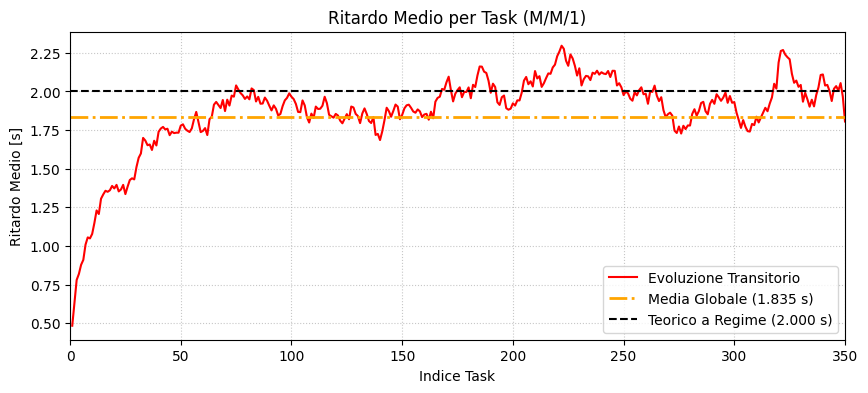

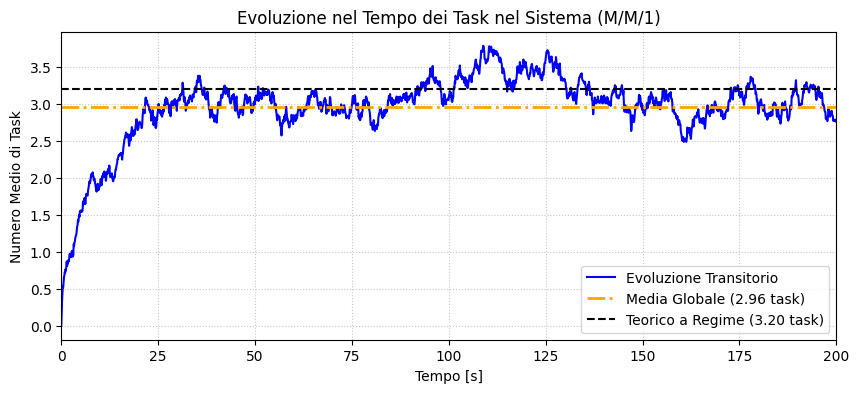

In [230]:
# ==========================================
# ESECUZIONE SIMULATORE: ENSEMBLE AVERAGE
# ==========================================

# 1. Definizione dei parametri fisici
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_test = 2.0 
f_loc_test = 2.5*1e8 

# Calcolo del tasso di servizio per le linee teoriche (mu = 1e9 / 1e8 = 10 task/s)
mu_rate = f_loc_test / params['C']
rho = lambda_test / mu_rate
print("Parametri di Simulazione:")
print(f"  - Lambda (tasso di arrivo): {lambda_test:.2f} task/s")
print(f"  - F_loc (frequenza di servizio): {f_loc_test:.2e} Hz")
print(f"  - Mu (tasso di servizio): {mu_rate:.2f} task/s")   

print(f"Avvio Simulazione... Carico teorico (rho): {lambda_test/mu_rate:.0%}")

# 2. Lancio delle 50 repliche indipendenti
# (Ricorda: la funzione restituisce 5 elementi, usiamo '_' per ignorare la matrice grezza se non ci serve)
t_grid, a_queue, a_util, a_delay, all_delays = run_multiple_sims(
    num_runs=150, 
    tasks_to_complete=500, 
    time_limit=200.0, 
    lambda_rate=lambda_test, 
    f_loc=f_loc_test, 
    params_Ks=params
)

print("Simulazioni completate! Generazione dei grafici...")

# 3. Plotting dei risultati con le baselines teoriche
plot_avg_delay(a_delay, lambda_test, mu_rate, zoom_tasks=350)  # Zoom sui primi 200 task per vedere meglio il transitorio
plot_avg_queue(t_grid, a_queue, lambda_test, mu_rate, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio



## 1.b

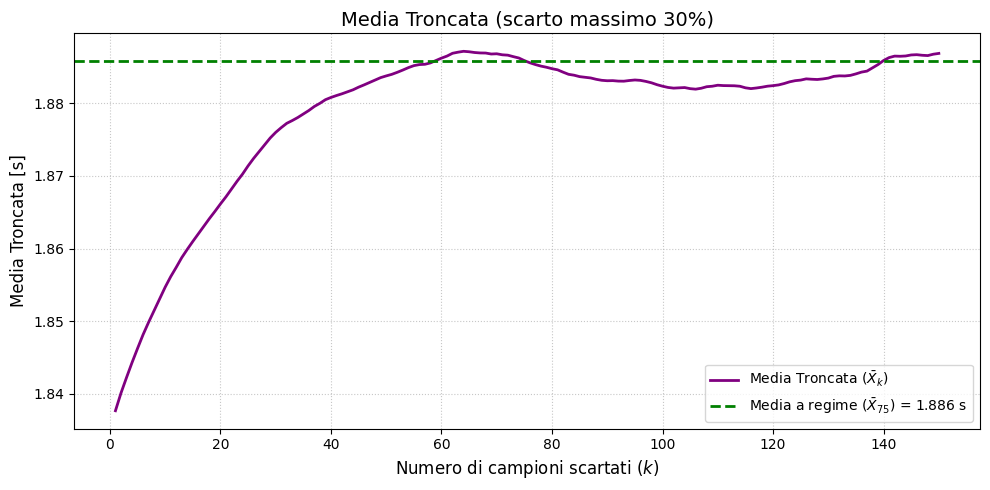

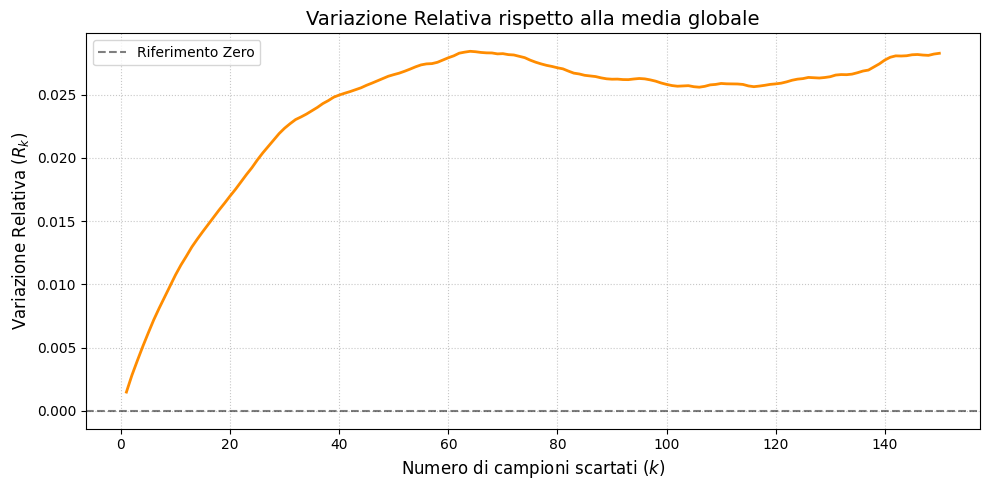

In [231]:
analyze_warmup(a_delay, max_discard_percent=0.3, k_star=75)

## 1.C

In [232]:
lambdas = [0.5, 1.0, 1.5, 2.0, 2.25]
results = []
mu = f_loc_test / params['C']  # Tasso di servizio basato sui parametri
k_star = 75  # Numero di task da scartare per il warm-up (da analisi precedente)
for lmb in lambdas:
        print(f"\n--- Analisi per Lambda = {lmb} (Rho = {lmb/2.5:.2f}) ---")
        
        # Lanciamo la simulazione pesante, spacchettando TUTTI e 5 i valori
        t_grid, a_queue, a_util, a_delay, matrice_grezza = run_multiple_sims(
            num_runs=525, 
            tasks_to_complete=500, 
            time_limit=200.0, 
            lambda_rate=lmb, 
            f_loc=2.5*1e8, 
            params_Ks=params,
            alpha=1.0 # o i tuoi eventuali altri parametri
        )
        # Analisi statistica a regime passando la MATRICE 2D
        mean_d, lb_d, ub_d = perform_statistical_analysis(matrice_grezza, k_star=k_star)
        t_warmup = k_star / lmb
        warmup_index = np.searchsorted(t_grid, t_warmup)
        steady_state_queue = np.mean(a_queue[warmup_index:])  # Media a regime escludendo il warm-up
        results.append({
            'lambda': lmb,
            'mean_delay': mean_d,
            'lb_delay': lb_d,
            'ub_delay': ub_d,
            'mean_queue': steady_state_queue
        })


--- Analisi per Lambda = 0.5 (Rho = 0.20) ---
----------------------------------------
RISULTATI ANALISI STATISTICA (A REGIME)
----------------------------------------
Repliche indipendenti: 525
Warm-up rimosso:       75 task
Media stimata:         0.4999 s
Intervallo Conf.95%: [0.4967, 0.5031] s
Margine di errore:     ±0.0032 s
----------------------------------------

--- Analisi per Lambda = 1.0 (Rho = 0.40) ---
----------------------------------------
RISULTATI ANALISI STATISTICA (A REGIME)
----------------------------------------
Repliche indipendenti: 525
Warm-up rimosso:       75 task
Media stimata:         0.6663 s
Intervallo Conf.95%: [0.6601, 0.6725] s
Margine di errore:     ±0.0062 s
----------------------------------------

--- Analisi per Lambda = 1.5 (Rho = 0.60) ---
----------------------------------------
RISULTATI ANALISI STATISTICA (A REGIME)
----------------------------------------
Repliche indipendenti: 525
Warm-up rimosso:       75 task
Media stimata:         0.99

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
C:\Users\gaspa\AppData\Local\Temp\ipykernel_21348\3959779448.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)


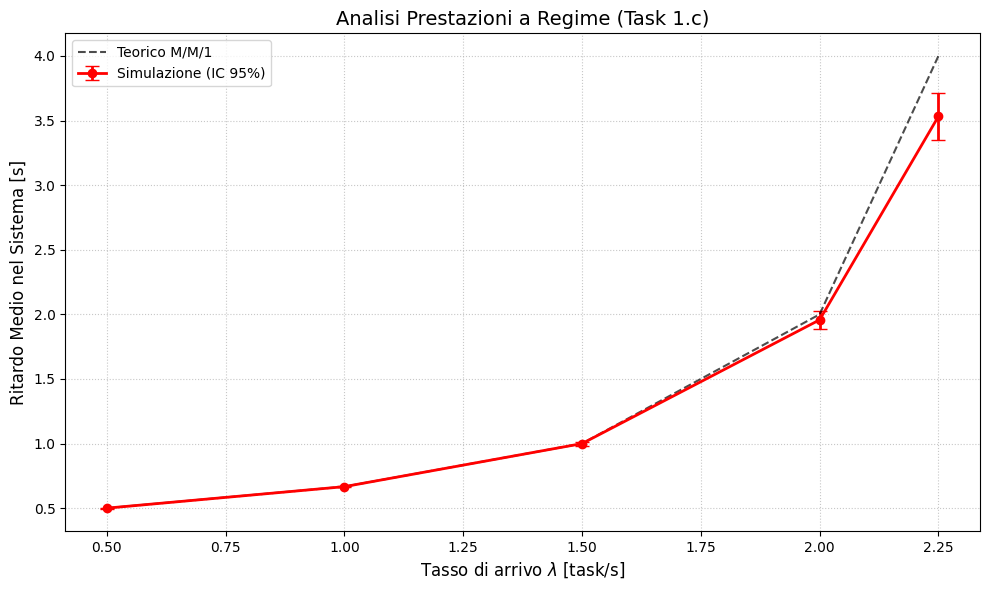

In [233]:
# 4. PLOTTING DELLA CURVA DI CARICO
lmb_vals = [r['lambda'] for r in results]
mean_delays = [r['mean_delay'] for r in results]
lb_vals = [r['lb_delay'] for r in results]
ub_vals = [r['ub_delay'] for r in results]

# Calcolo errori per la barra di errore
lower_error = np.array(mean_delays) - np.array(lb_vals)
upper_error = np.array(ub_vals) - np.array(mean_delays)

plt.figure(figsize=(10, 6))
# I tuoi dati simulati con l'intervallo di confidenza
plt.errorbar(lmb_vals, mean_delays, yerr=[lower_error, upper_error], 
             fmt='o-', color='red', capsize=5, label='Simulazione (IC 95%)', linewidth=2)

# La curva teorica M/M/1 (Ritardo E[T] = 1 / (mu - lambda))
teorico = [1 / (mu - l) for l in lmb_vals]
plt.plot(lmb_vals, teorico, 'k--', label='Teorico M/M/1', alpha=0.7)

plt.title("Analisi Prestazioni a Regime (Task 1.c)", fontsize=14)
plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)
plt.ylabel("Ritardo Medio nel Sistema [s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
C:\Users\gaspa\AppData\Local\Temp\ipykernel_21348\484229162.py:16: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)


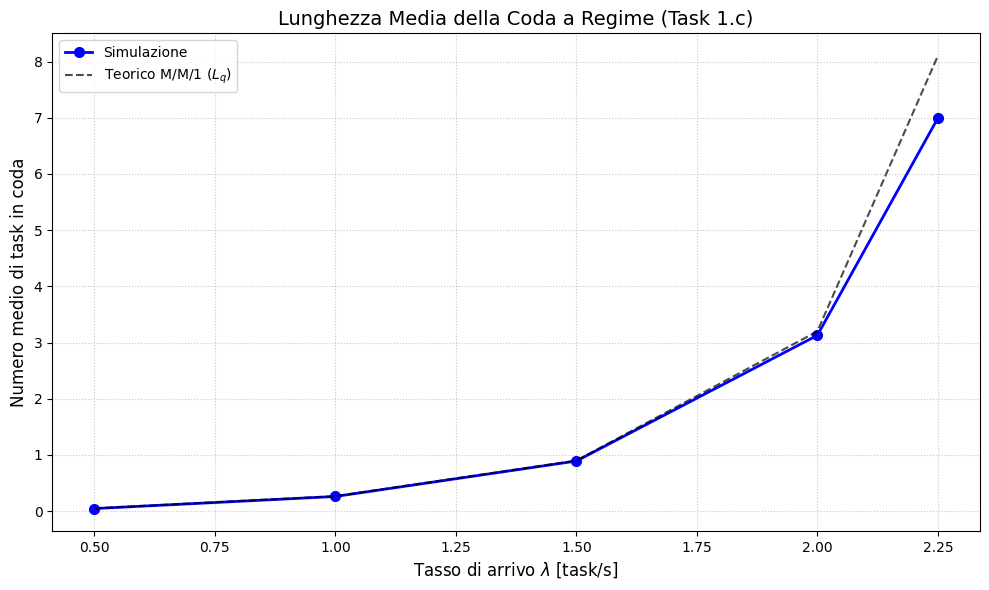

In [234]:
# Estrazione dati della coda dai risultati già calcolati
mean_queues = [r['mean_queue'] for r in results]
rhos = [lmb / mu for lmb in lmb_vals]

plt.figure(figsize=(10, 6))

# Plot dei dati simulati
plt.plot(lmb_vals, mean_queues, 'o-', color='blue', label='Simulazione', linewidth=2, markersize=7)

# Calcolo e plot della curva teorica M/M/1 (Lunghezza della coda d'attesa)
# Formula: Lq = rho^2 / (1 - rho)
teorico_coda = [(r**2) / (1 - r) for r in rhos]
plt.plot(lmb_vals, teorico_coda, 'k--', label='Teorico M/M/1 ($L_q$)', alpha=0.7)

plt.title("Lunghezza Media della Coda a Regime (Task 1.c)", fontsize=14)
plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)
plt.ylabel("Numero medio di task in coda", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## TASK 2

In [235]:
#funzione per generare i task in arrivo distruibuendoli tra HAPS e nodo locale
def task_generation_with_offloading(time, FES, node, haps, alpha, params_Ks, params_Kt, event_counter, probability_offload=0):
    inter_arrival = random.expovariate(node.lambda_rate)
    heapq.heappush(FES, (time + inter_arrival, next(event_counter), 'task_generation', node, alpha, params_Ks, params_Kt, event_counter))
    
    # Generazione Task
    if random.random() <= alpha:
        task = Task(time, "K_s", params_Ks['L'], params_Ks['C'], params_Ks['D_max'])
    else:
        task = Task(time, "K_t", params_Kt['L'], params_Kt['C'], params_Kt['D_max'])
        
    node.stats.update_time_averages(time, len(node.queue), 1 if node.server_busy else 0)
    
    # Decisione di offloading
    if random.random() < probability_offload:
        # Offload al HAPS
        heapq.heappush(FES, (time, next(event_counter), 'offload_to_haps', haps, task, event_counter))
    else:
        if not node.server_busy:
            node.server_busy = True
            
            actual_C = random.expovariate(1.0 / task.C)
            T_s = actual_C / node.f_loc
            
            heapq.heappush(FES, (time + T_s, next(event_counter), 'local_departure', node, task, event_counter))
        else:
            node.queue.append(task)

In [236]:
#funzione per calcolare il tempo di arrivo di una task inviata dall'HAPS usando un parametro R_ur and L della task
def haps_arrival(time, FES, node, task, event_counter, R_ur=5e8):
    # Calcolo del tempo di arrivo al HAPS (trasmissione + ritardo di rete)
    
    if not node.server_busy:
            node.server_busy = True
            
            actual_C = random.expovariate(1.0 / task.C)
            T_s = actual_C / node.f_loc
            network_delay = task.L/R_ur
            arrival_time_haps = time + network_delay+T_s
            
            heapq.heappush(FES, (arrival_time_haps, next(event_counter), 'local_departure', node, task, event_counter))
    else:
            node.queue.append(task)
    
    

In [237]:
def run_sim_haps_node(tasks_to_complete, lambda_rate, f_loc_node, f_loc_haps, params_Ks, params_Kt=None, alpha=1.0, seed=42, probability_offload=0, R_ur=5e8):
    random.seed(seed)
    event_counter = itertools.count() 
    FES = []
    
    node = SensingNode(node_id=1, f_loc=f_loc_node, lambda_rate=lambda_rate)
    haps= SensingNode(node_id=0, f_loc=f_loc_haps, lambda_rate=0)  # HAPS più veloce e con meno arrivi
    
    # Innesco del sistema a vuoto
    heapq.heappush(FES, (0.0, next(event_counter), 'task_generation', node, alpha, params_Ks, params_Kt, event_counter))
    
    time_points = [0.0]
    queue_lengths_node = [0]
    server_status_node = [0.0]
    queue_lengths_haps = [0]
    server_status_haps = [0.0]
    
    current_time = 0.0
    
    while len(node.stats.delay_list) + len(haps.stats.delay_list)<tasks_to_complete and len(FES) > 0:
        event_time, _, event_type, *args = heapq.heappop(FES)
        current_time = event_time
        
        if event_type == 'task_generation':
            task_generation_with_offloading(current_time, FES, args[0], haps, args[1], args[2], args[3], args[4], probability_offload)
        elif event_type == 'local_departure':
            local_departure(current_time, FES, args[0], args[1], args[2])
        elif event_type == 'offload_to_haps':
            haps_arrival(current_time, FES, args[0], args[1], args[2],R_ur)
        
            
        time_points.append(current_time)
        queue_lengths_node.append(len(node.queue))
        server_status_node.append(1.0 if node.server_busy else 0.0)
        queue_lengths_haps.append(len(haps.queue))
        server_status_haps.append(1.0 if haps.server_busy else 0.0)
        
    return node.stats.delay_list, haps.stats.delay_list, time_points, queue_lengths_node, server_status_node, queue_lengths_haps, server_status_haps

In [238]:
def run_multiple_sims_node_HAPS_interaction(num_runs, tasks_to_complete, time_limit, lambda_rate, f_loc_node, f_loc_haps, params_Ks, params_Kt=None, alpha=1.0, probability_offload=0.0, R_ur=5e8):
    all_delays = np.zeros((num_runs, tasks_to_complete))
    
    # Griglia temporale fissa per le metriche continue (10 campioni/s)
    num_samples = int(time_limit * 10) 
    time_grid = np.linspace(0, time_limit, num_samples)
    
    sum_queues_node = np.zeros(num_samples)
    sum_utils_node = np.zeros(num_samples)
    sum_queues_haps = np.zeros(num_samples)
    sum_utils_haps = np.zeros(num_samples)

    
    for i in range(num_runs):
        
        delays_node, delays_haps, t_pts, q_lens, s_stats, q_lens_haps, s_stats_haps = run_sim_haps_node(
            tasks_to_complete=tasks_to_complete, 
            lambda_rate=lambda_rate, 
            f_loc_node=f_loc_node, 
            f_loc_haps=f_loc_haps, 
            params_Ks=params_Ks, 
            params_Kt=params_Kt, 
            alpha=alpha, 
            seed=(42+i),
            probability_offload=probability_offload,
            R_ur=R_ur
        )
        
    
        all_delays[i, :] = delays_node[:tasks_to_complete]+ delays_haps[:tasks_to_complete-len(delays_node)]  # Consideriamo solo i ritardi del nodo locale per l'analisi a regime

        # Interpolazione a gradini
        f_q = interp1d(t_pts, q_lens, kind='previous', fill_value="extrapolate")
        f_s = interp1d(t_pts, s_stats, kind='previous', fill_value="extrapolate")
        f_q_haps = interp1d(t_pts, q_lens_haps, kind='previous', fill_value="extrapolate")
        f_s_haps = interp1d(t_pts, s_stats_haps, kind='previous', fill_value="extrapolate")
        
        sum_queues_node += f_q(time_grid)
        sum_utils_node += f_s(time_grid)
        sum_queues_haps += f_q_haps(time_grid)
        sum_utils_haps += f_s_haps(time_grid)
        
    # Calcolo delle Ensemble Averages
    avg_queue_node = sum_queues_node / num_runs
    avg_utilization_node = sum_utils_node / num_runs
    avg_queue_haps = sum_queues_haps / num_runs
    avg_utilization_haps = sum_utils_haps / num_runs
    avg_delay = np.mean(all_delays, axis=0) 
    
    return time_grid, avg_queue_node, avg_utilization_node, avg_queue_haps, avg_utilization_haps, avg_delay, all_delays

## 2.a

Avvio Simulazione con haps... Carico teorico (rho): 40%
Simulazioni completate! Generazione dei grafici...


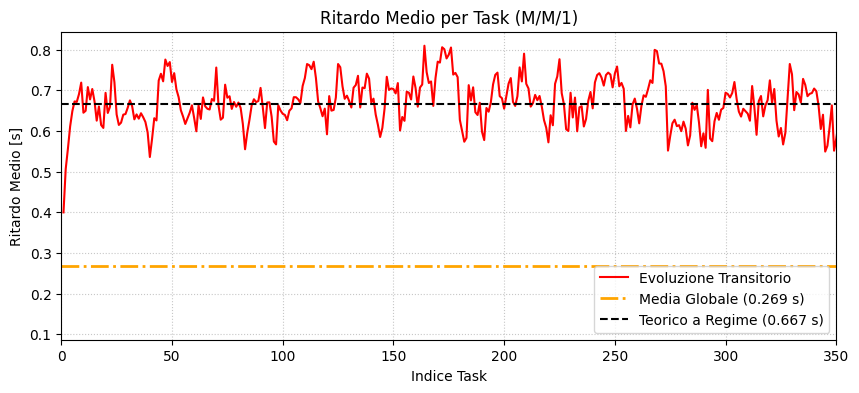

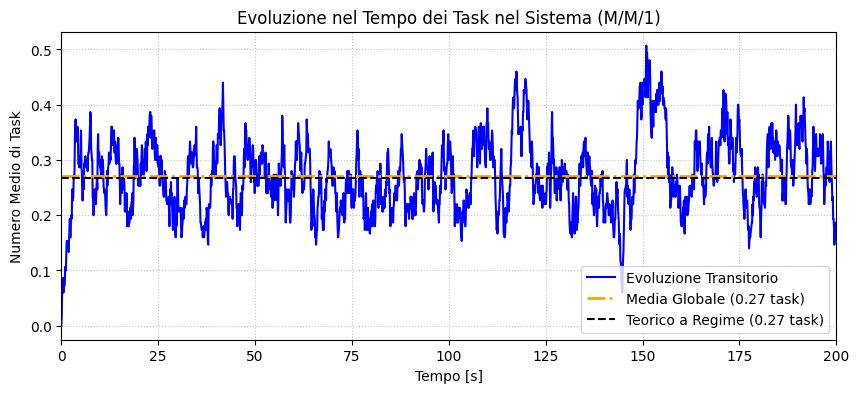

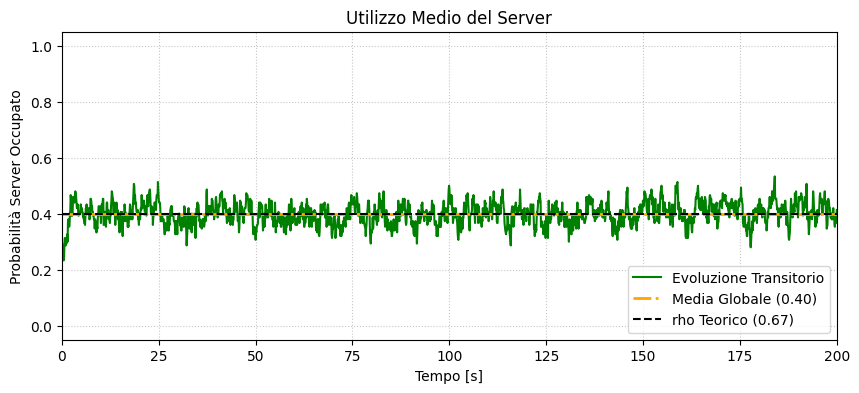

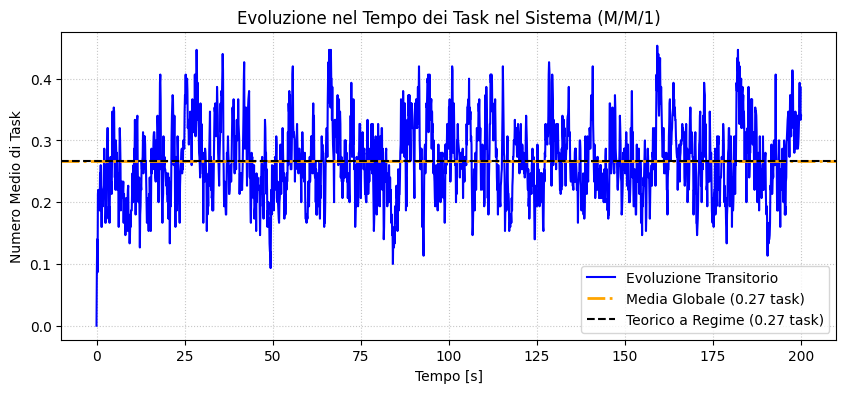

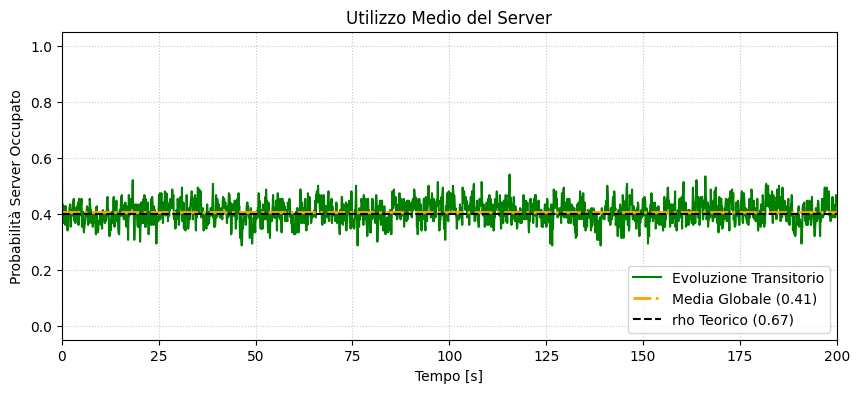

In [278]:
# ==========================================
# ESECUZIONE SIMULATORE: ENSEMBLE AVERAGE
# ==========================================

# 1. Definizione dei parametri fisici
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_node = 5 
f_loc_node = 2.5*1e8 
f_loc_haps = 1*1e9  # HAPS più veloce del nodo locale
# Calcolo del tasso di servizio per le linee teoriche (mu = 1e9 / 1e8 = 10 task/s)
mu_rate = f_loc_test / params['C']
mu_rate_haps = f_loc_haps / params['C']
probability_offload = 0.8 # 30% dei task vengono offloadati al HAPS    
rho_node= max(lambda_node*probability_offload/ mu_rate_haps , lambda_node*(1-probability_offload)/ mu_rate)
print(f"Avvio Simulazione con haps... Carico teorico (rho): {rho_node:.0%}")

# 2. Lancio delle 50 repliche indipendenti
# (Ricorda: la funzione restituisce 5 elementi, usiamo '_' per ignorare la matrice grezza se non ci serve)
t_grid, a_queue, a_util, a_queue_haps, a_util_haps, a_delay, all_delays = run_multiple_sims_node_HAPS_interaction(
    num_runs=150, 
    tasks_to_complete=2500, 
    time_limit=200.0, 
    lambda_rate=lambda_node, 
    f_loc_node=f_loc_node, 
    f_loc_haps=f_loc_haps,
    params_Ks=params,
    alpha=1.0,
    probability_offload=probability_offload  # 30% dei task vengono offloadati al HAPS
)


print("Simulazioni completate! Generazione dei grafici...")

# 3. Plotting dei risultati con le baselines teoriche
plot_avg_delay(a_delay, lambda_node*(1-probability_offload), mu_rate, zoom_tasks=350)
plot_avg_queue(t_grid, a_queue, lambda_node*(1-probability_offload), mu_rate, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio
plot_avg_utilization(t_grid, a_util, lambda_node*(1-probability_offload), mu_rate, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio

 # Zoom sui primi 200 task per vedere meglio il transitorio
plot_avg_queue(t_grid, a_queue_haps, lambda_node*probability_offload, mu_rate_haps)  # Zoom sui primi 200 secondi per vedere meglio il transitorio
plot_avg_utilization(t_grid, a_util_haps, lambda_node*probability_offload, mu_rate_haps, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio

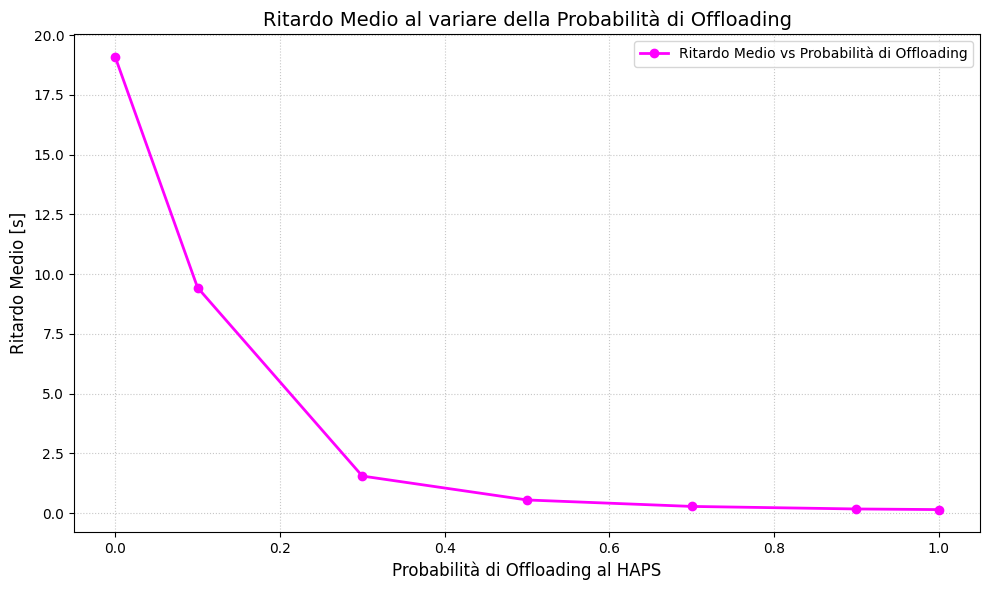

In [240]:
# mostra come cambia il ritardo medio al variare della probabilità di offloading

##DOMANDA, così cambia anche lambda! come faccio ad avere qualcosa di normale?
#Forse quello che dovrei decidere è R_ru
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_node = 3.0 
f_loc_node = 2.5*1e8 
f_loc_haps = 1*1e9 
probabilities = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
mean_delays = []
for p in probabilities:
    _, _, _, _, _, a_delay, _ = run_multiple_sims_node_HAPS_interaction(
        num_runs=150, 
        tasks_to_complete=500, 
        time_limit=200.0, 
        lambda_rate=lambda_node, 
        f_loc_node=f_loc_node, 
        f_loc_haps=f_loc_haps,
        params_Ks=params,
        alpha=1.0,
        probability_offload=p
    )
    mean_delays.append(np.mean(a_delay))
plt.figure(figsize=(10, 6))
plt.plot(probabilities, mean_delays, 'o-', color='magenta', label='Ritardo Medio vs Probabilità di Offloading', linewidth=2)
plt.title("Ritardo Medio al variare della Probabilità di Offloading", fontsize=14)
plt.xlabel("Probabilità di Offloading al HAPS", fontsize=12)
plt.ylabel("Ritardo Medio [s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


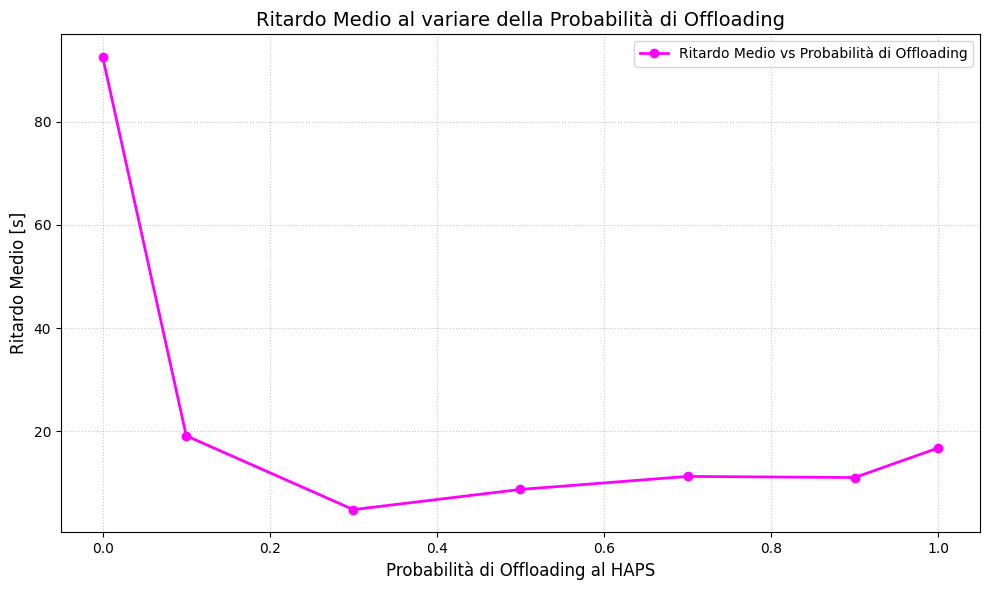

In [241]:
# mostra come cambia il ritardo medio al variare della probabilità di offloading

##DOMANDA, così cambia anche lambda! come faccio ad avere qualcosa di normale?
#Forse quello che dovrei decidere è R_ru
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_node = 30.0 
f_loc_node = 2.5*1e8 
f_loc_haps = 1*1e9 
probabilities = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
mean_delays = []
for p in probabilities:
    _, _, _, _, _, a_delay, _ = run_multiple_sims_node_HAPS_interaction(
        num_runs=150, 
        tasks_to_complete=500, 
        time_limit=200.0, 
        lambda_rate=lambda_node, 
        f_loc_node=f_loc_node, 
        f_loc_haps=f_loc_haps,
        params_Ks=params,
        alpha=1.0,
        probability_offload=p
    )
    mean_delays.append(np.mean(a_delay))
plt.figure(figsize=(10, 6))
plt.plot(probabilities, mean_delays, 'o-', color='magenta', label='Ritardo Medio vs Probabilità di Offloading', linewidth=2)
plt.title("Ritardo Medio al variare della Probabilità di Offloading", fontsize=14)
plt.xlabel("Probabilità di Offloading al HAPS", fontsize=12)
plt.ylabel("Ritardo Medio [s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


In [242]:
# # mostra come cambia il ritardo medio al variare della probabilità di offloading

# ##DOMANDA, così cambia anche lambda! come faccio ad avere qualcosa di normale?
# #Forse quello che dovrei decidere è R_ru
# R_ur_vector = [5e7,1e8, 5e8, 1e9, 5e9, 1e10]  # Variazione del parametro R_ur
# mean_delays = []
# for R_ur in R_ur_vector:
#     _, _, _, _, _, a_delay, _ = run_multiple_sims_node_HAPS_interaction(
#         num_runs=150, 
#         tasks_to_complete=500, 
#         time_limit=200.0, 
#         lambda_rate=lambda_node, 
#         f_loc_node=f_loc_node, 
#         f_loc_haps=f_loc_haps,
#         params_Ks=params,
#         alpha=1.0,
#         probability_offload=0.5,
#         R_ur=R_ur
        
#     )
#     mean_delays.append(np.mean(a_delay))
#     print("prims)")
# plt.figure(figsize=(10, 6))
# plt.plot(R_ur_vector, mean_delays, 'o-', color='magenta', label='Ritardo Medio vs R_ur', linewidth=2)
# plt.xscale('log')
# plt.title("Ritardo Medio al variare di R_ur", fontsize=14)
# plt.xlabel("R_ur (bps)", fontsize=12)
# plt.ylabel("Ritardo Medio [s]", fontsize=12)
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.legend()
# plt.tight_layout()
# plt.show()



In [243]:
# #mostra una serie di grafici con cambiamento di probabilità e anche del parametro R_ur combinati insieme
# R_ur_vector = [9e5,1e8, 5e8, 1e9, 5e9, 1e10]  # Variazione del parametro R_ur
# probabilities = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
# results = {}
# for R_ur in R_ur_vector:
#     mean_delays = []
#     for p in probabilities:
#         _, _, _, _, _, a_delay, _ = run_multiple_sims_node_HAPS_interaction(
#             num_runs=150, 
#             tasks_to_complete=500, 
#             time_limit=200.0, 
#             lambda_rate=lambda_node, 
#             f_loc_node=f_loc_node, 
#             f_loc_haps=f_loc_haps,
#             params_Ks=params,
#             alpha=1.0,
#             probability_offload=p,
#             R_ur=R_ur
            
#         )
#         mean_delays.append(np.mean(a_delay))
#     results[R_ur] = mean_delays
# plt.figure(figsize=(12, 8))
# #plot dei dati simulati tutti nello stesso grafico
# for R_ur, mean_delays in results.items():
#     plt.plot(probabilities, mean_delays, 'o-', label=f'R_ur = {R_ur:.1e} bps', linewidth=2)
# plt.title("Ritardo Medio al variare della Probabilità di Offloading per diversi R_ur", fontsize=14)
# plt.xlabel("Probabilità di Offloading al HAPS", fontsize=12)
# plt.ylabel("Ritardo Medio [s]", fontsize=12)
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.legend()
# plt.tight_layout()
# plt.show()

#### Multiple time

In [258]:
# Modifica del ciclo di simulazione per avere una lista di nodi sensori e un HAPS
def run_sim_multiple_nodes_with_haps(tasks_to_complete, lambda_rate, f_loc_node, f_loc_haps, params_Ks, params_Kt=None, alpha=1.0, seed=42, probability_offload=0.0, R_ur=5e8, num_nodes=3):
    random.seed(seed)
    event_counter = itertools.count() 
    FES = []
    
    # Creazione dei nodi sensori
    nodes = [SensingNode(node_id=i+1, f_loc=f_loc_node, lambda_rate=lambda_rate[i]) for i in range(num_nodes)]
    haps = SensingNode(node_id=0, f_loc=f_loc_haps, lambda_rate=0)  # HAPS più veloce e con meno arrivi
    
    # Innesco del sistema a vuoto per ogni nodo
    for node in nodes:
        heapq.heappush(FES, (0.0, next(event_counter), 'task_generation', node, alpha, params_Ks, params_Kt, event_counter))
    
    time_points = [0.0]
    queue_lengths_nodes = [[0] for _ in range(num_nodes)]
    server_status_nodes = [[0.0] for _ in range(num_nodes)]
    queue_lengths_haps = [0]
    server_status_haps = [0.0]
    
    current_time = 0.0
    
    while sum(len(node.stats.delay_list) for node in nodes) + len(haps.stats.delay_list) < tasks_to_complete and len(FES) > 0:
        event_time, _, event_type, *args = heapq.heappop(FES)
        current_time = event_time
        
        if event_type == 'task_generation':
            task_generation_with_offloading(current_time, FES, args[0], haps, args[1], args[2], args[3], args[4], probability_offload)
        elif event_type == 'local_departure':
            local_departure(current_time, FES, args[0], args[1], args[2])
        elif event_type == 'offload_to_haps':
            haps_arrival(current_time, FES, args[0], args[1], args[2],R_ur)
        
        time_points.append(current_time)
        for i, node in enumerate(nodes):
            queue_lengths_nodes[i].append(len(node.queue))
            server_status_nodes[i].append(1.0 if node.server_busy else 0.0)
        queue_lengths_haps.append(len(haps.queue))
        server_status_haps.append(1.0 if haps.server_busy else 0.0)
        
    return [node.stats.delay_list for node in nodes], haps.stats.delay_list, time_points, queue_lengths_nodes, server_status_nodes, queue_lengths_haps, server_status_haps

In [259]:
#multiple sims per multiple nodes
def run_multiple_sims_multiple_nodes(num_runs, tasks_to_complete, time_limit, lambda_rate, f_loc_node, f_loc_haps, params_Ks, params_Kt=None, alpha=1.0, probability_offload=0.0, R_ur=5e8, num_nodes=3):
    all_delays = np.zeros((num_runs, num_nodes, tasks_to_complete))
    
    # Griglia temporale fissa per le metriche continue (10 campioni/s)
    num_samples = int(time_limit * 10) 
    time_grid = np.linspace(0, time_limit, num_samples)
    
    sum_queues_nodes = [np.zeros(num_samples) for _ in range(num_nodes)]
    sum_utils_nodes = [np.zeros(num_samples) for _ in range(num_nodes)]
    sum_queues_haps = np.zeros(num_samples)
    sum_utils_haps = np.zeros(num_samples)

    
    for i in range(num_runs):
        
        delays_nodes, delays_haps, t_pts, q_lens_nodes, s_stats_nodes, q_lens_haps, s_stats_haps = run_sim_multiple_nodes_with_haps(
            tasks_to_complete=tasks_to_complete, 
            lambda_rate=lambda_rate, 
            f_loc_node=f_loc_node, 
            f_loc_haps=f_loc_haps,
            params_Ks=params_Ks,
            params_Kt=params_Kt,
            alpha=alpha,
            seed=(42+i),
            probability_offload=probability_offload,
            R_ur=R_ur,
            num_nodes=num_nodes
        )
        delay_array=[]
        for j in range(num_nodes):
            delay_array+=delays_nodes[j][:tasks_to_complete]
        delay_array+=delays_haps[:tasks_to_complete-len(delay_array)]
        all_delays[i, :] = delay_array # Consideriamo solo i ritardi del nodo locale per l'analisi a regime

        # Interpolazione a gradini per ogni nodo
        for j in range(num_nodes):
            f_q_node = interp1d(t_pts, q_lens_nodes[j], kind='previous', fill_value="extrapolate")
            f_s_node = interp1d(t_pts, s_stats_nodes[j], kind='previous', fill_value="extrapolate")
            sum_queues_nodes[j] += f_q_node(time_grid)
            sum_utils_nodes[j] += f_s_node(time_grid)
        
        # Interpolazione per HAPS
        f_q_haps = interp1d(t_pts, q_lens_haps, kind='previous', fill_value="extrapolate")
        f_s_haps = interp1d(t_pts, s_stats_haps, kind='previous', fill_value="extrapolate")
        sum_queues_haps += f_q_haps(time_grid)
        sum_utils_haps += f_s_haps(time_grid)
    # Calcolo delle Ensemble Averages
    avg_queues_nodes = [sum_q / num_runs for sum_q in sum_queues_nodes]
    avg_utils_nodes = [sum_u / num_runs for sum_u in sum_utils_nodes]
    avg_queues_haps = sum_queues_haps / num_runs
    avg_utils_haps = sum_utils_haps / num_runs
    avg_delays = np.mean(all_delays, axis=0)   # Media dei ritardi per ogni nodo
    return time_grid, avg_queues_nodes, avg_utils_nodes, avg_queues_haps, avg_utils_haps, avg_delays, all_delays

Avvio Simulazione con haps... Carico teorico (rho): 100%
Simulazioni completate! Generazione dei grafici...


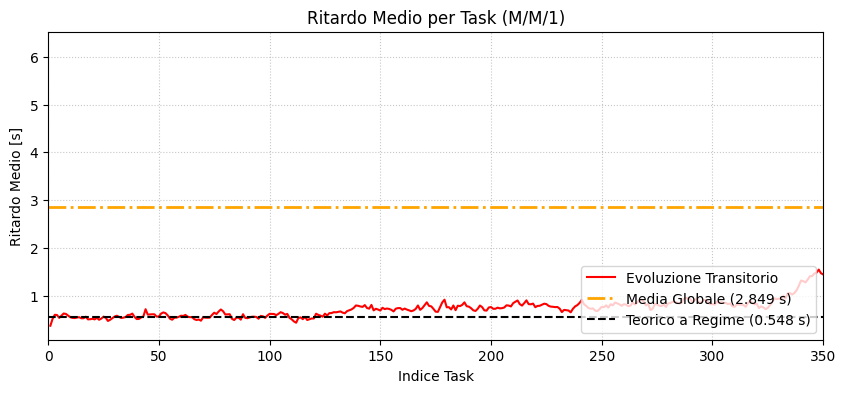

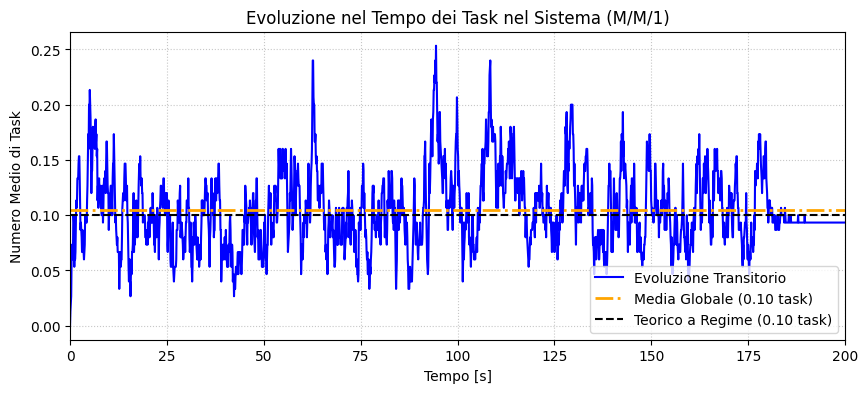

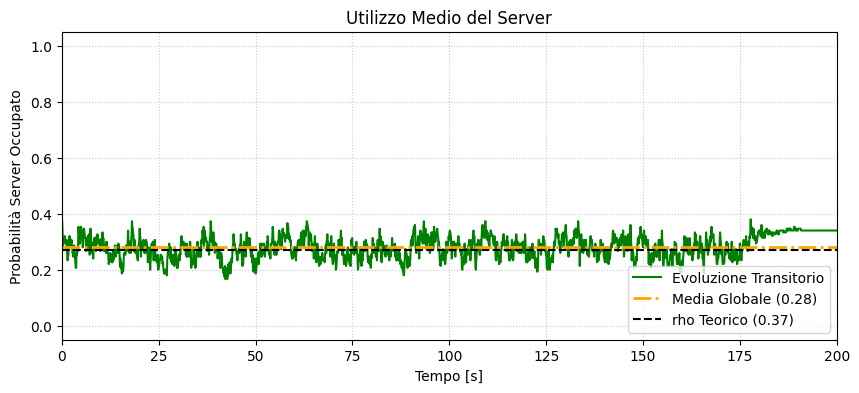

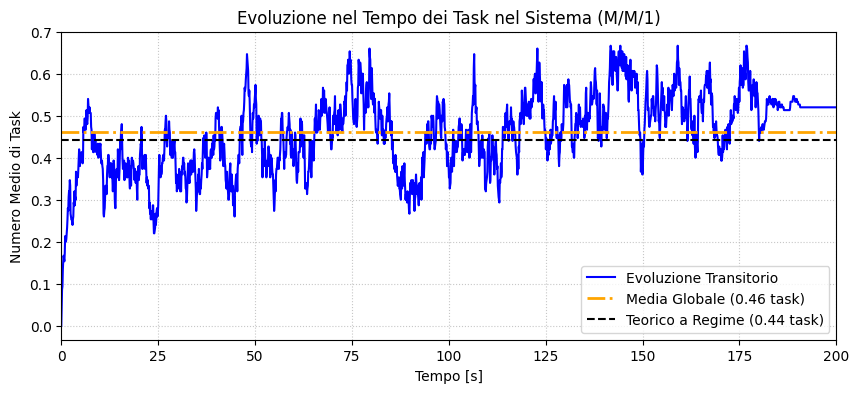

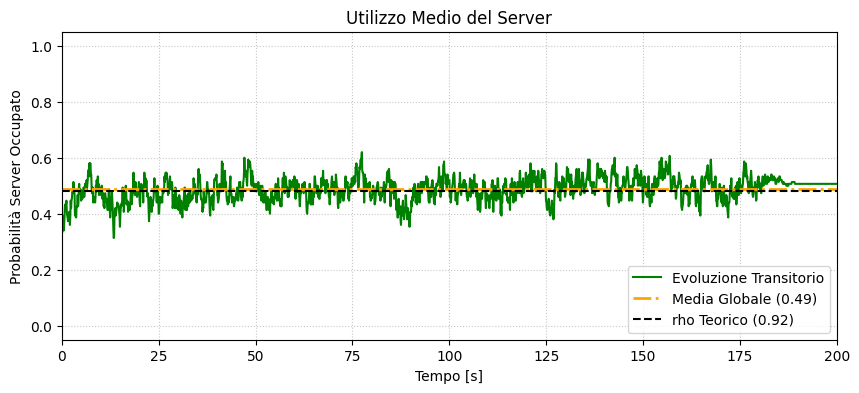

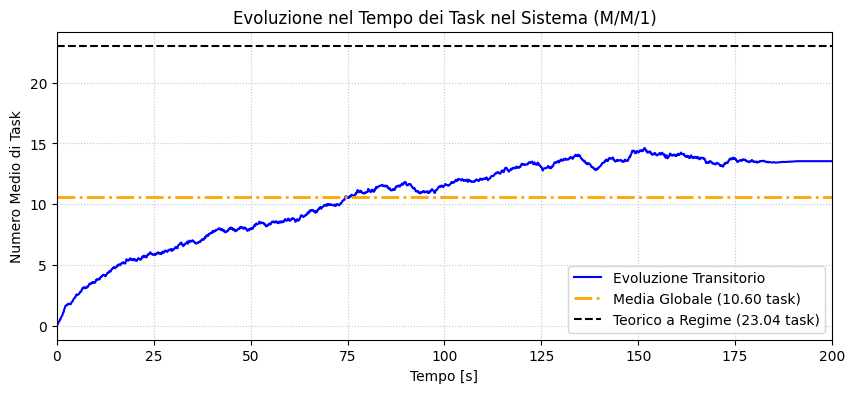

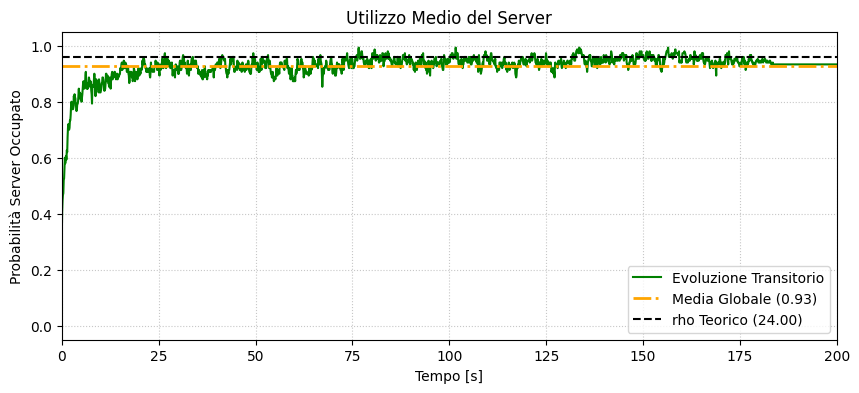

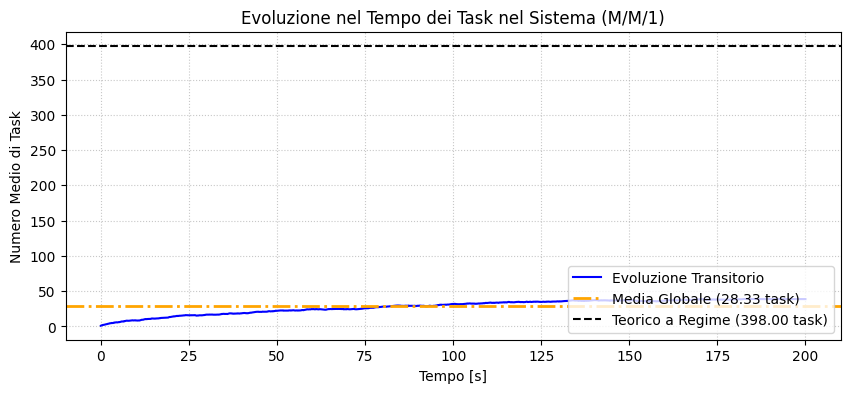

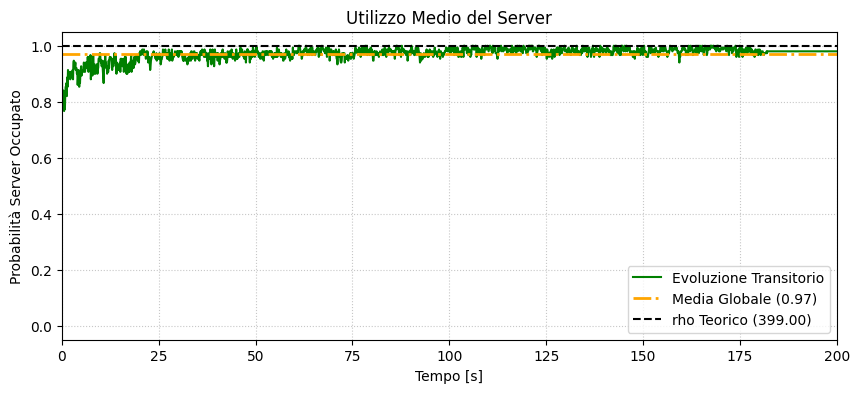

In [264]:
#main comandi con plot per più nodi
# ==========================================
# ESECUZIONE SIMULATORE: ENSEMBLE AVERAGE
# ==========================================

# 1. Definizione dei parametri fisici
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_node = [2.25, 4, 8]  # Stesso tasso di arrivo per tutti i nodi 
f_loc_node = 2.5*1e8 
f_loc_haps = 1*1e9  # HAPS più veloce del nodo locale
num_nodes = 3  # Numero di nodi sensori
probability_offload = 0.3  # 30% dei task vengono offloadati al HAPS
# Calcolo del tasso di servizio per le linee teoriche (mu = 1e9 / 1e8 = 10 task/s)
mu_rate = f_loc_test / params['C']
mu_rate_haps = f_loc_haps / params['C']
probability_offload = 0.7 # 30% dei task vengono offloadati al HAPS    
rho_node= max(sum(lambda_node)*probability_offload/ mu_rate_haps , max(lambda_node)*(1-probability_offload)/ mu_rate)
print(f"Avvio Simulazione con haps... Carico teorico (rho): {rho_node:.0%}")

# 2. Lancio delle 50 repliche indipendenti
# (Ricorda: la funzione restituisce 5 elementi, usiamo '_' per ignorare la matrice grezza se non ci serve)
t_grid, a_queue, a_util, a_queue_haps, a_util_haps, a_delay, all_delays = run_multiple_sims_multiple_nodes(
    num_runs=150, 
    tasks_to_complete=2500, 
    time_limit=200.0, 
    lambda_rate=lambda_node, 
    f_loc_node=f_loc_node, 
    f_loc_haps=f_loc_haps,
    params_Ks=params,
    alpha=1.0,
    probability_offload=probability_offload,  # 30% dei task vengono offloadati al HAPS
    num_nodes=num_nodes
)


print("Simulazioni completate! Generazione dei grafici...")
plot_avg_delay(a_delay[j], lambda_node[0]*(1-probability_offload), mu_rate, zoom_tasks=350)
for j in range(num_nodes): # Zoom sui primi 200 task per vedere meglio il transitorio
    plot_avg_queue(t_grid, a_queue[j], lambda_node[j]*(1-probability_offload), mu_rate, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio
    plot_avg_utilization(t_grid, a_util[j], lambda_node[j]*(1-probability_offload), mu_rate, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio

 # Zoom sui primi 200 task per vedere meglio il transitorio
plot_avg_queue(t_grid, a_queue_haps, sum(lambda_node)*probability_offload, mu_rate_haps)  # Zoom sui primi 200 secondi per vedere meglio il transitorio
plot_avg_utilization(t_grid, a_util_haps, sum(lambda_node)*probability_offload, mu_rate_haps, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio

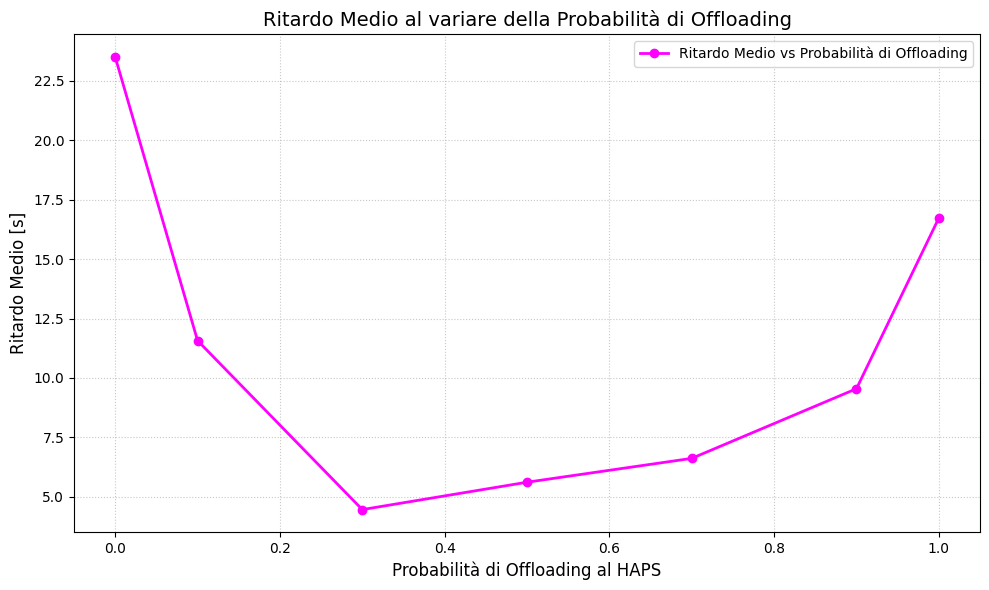

In [266]:
# mostra come cambia il ritardo medio al variare della probabilità di offloading

##DOMANDA, così cambia anche lambda! come faccio ad avere qualcosa di normale?
#Forse quello che dovrei decidere è R_ru
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_node = [5.0, 10.0, 15.0]  # Tassi di arrivo per i tre nodi
f_loc_node = 2.5*1e8 
f_loc_haps = 1*1e9 
probabilities = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
mean_delays = []
num_nodes = len(lambda_node)
for p in probabilities:
    _, _, _, _, _, a_delay, _ = run_multiple_sims_multiple_nodes(
        num_runs=150, 
        tasks_to_complete=500, 
        time_limit=200.0, 
        lambda_rate=lambda_node, 
        f_loc_node=f_loc_node, 
        f_loc_haps=f_loc_haps,
        params_Ks=params,
        alpha=1.0,
        probability_offload=p,
        num_nodes=num_nodes
    )
    mean_delays.append(np.mean(a_delay))
plt.figure(figsize=(10, 6))
plt.plot(probabilities, mean_delays, 'o-', color='magenta', label='Ritardo Medio vs Probabilità di Offloading', linewidth=2)
plt.title("Ritardo Medio al variare della Probabilità di Offloading", fontsize=14)
plt.xlabel("Probabilità di Offloading al HAPS", fontsize=12)
plt.ylabel("Ritardo Medio [s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


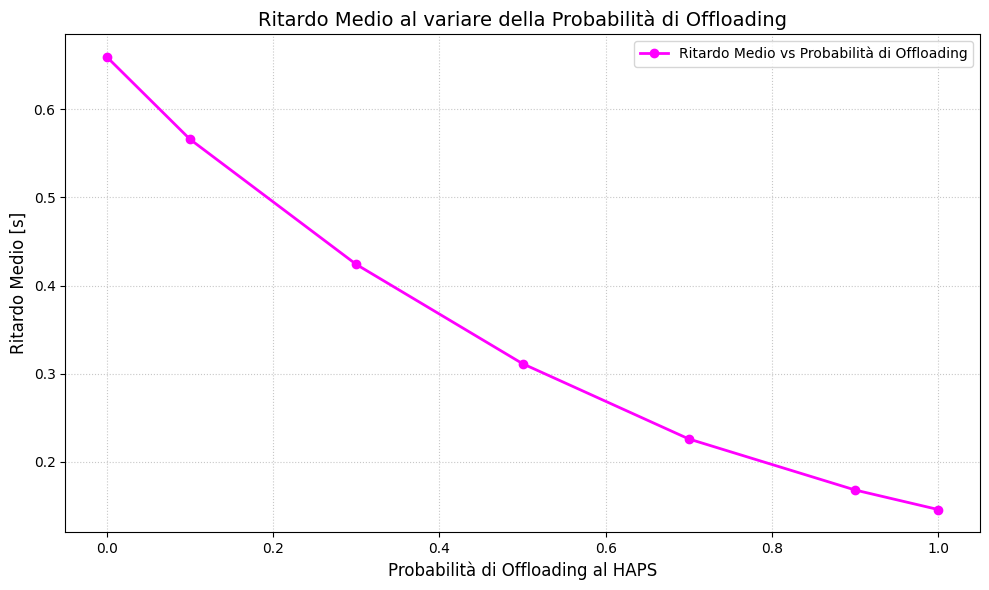

In [268]:
# mostra come cambia il ritardo medio al variare della probabilità di offloading

##DOMANDA, così cambia anche lambda! come faccio ad avere qualcosa di normale?
#Forse quello che dovrei decidere è R_ru
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_node = [1.0, 1.0, 1.0]  # Tassi di arrivo per i tre nodi
f_loc_node = 2.5*1e8 
f_loc_haps = 1*1e9 
probabilities = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
mean_delays = []
num_nodes = len(lambda_node)
for p in probabilities:
    _, _, _, _, _, a_delay, _ = run_multiple_sims_multiple_nodes(
        num_runs=150, 
        tasks_to_complete=500, 
        time_limit=200.0, 
        lambda_rate=lambda_node, 
        f_loc_node=f_loc_node, 
        f_loc_haps=f_loc_haps,
        params_Ks=params,
        alpha=1.0,
        probability_offload=p,
        num_nodes=num_nodes
    )
    mean_delays.append(np.mean(a_delay))
plt.figure(figsize=(10, 6))
plt.plot(probabilities, mean_delays, 'o-', color='magenta', label='Ritardo Medio vs Probabilità di Offloading', linewidth=2)
plt.title("Ritardo Medio al variare della Probabilità di Offloading", fontsize=14)
plt.xlabel("Probabilità di Offloading al HAPS", fontsize=12)
plt.ylabel("Ritardo Medio [s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


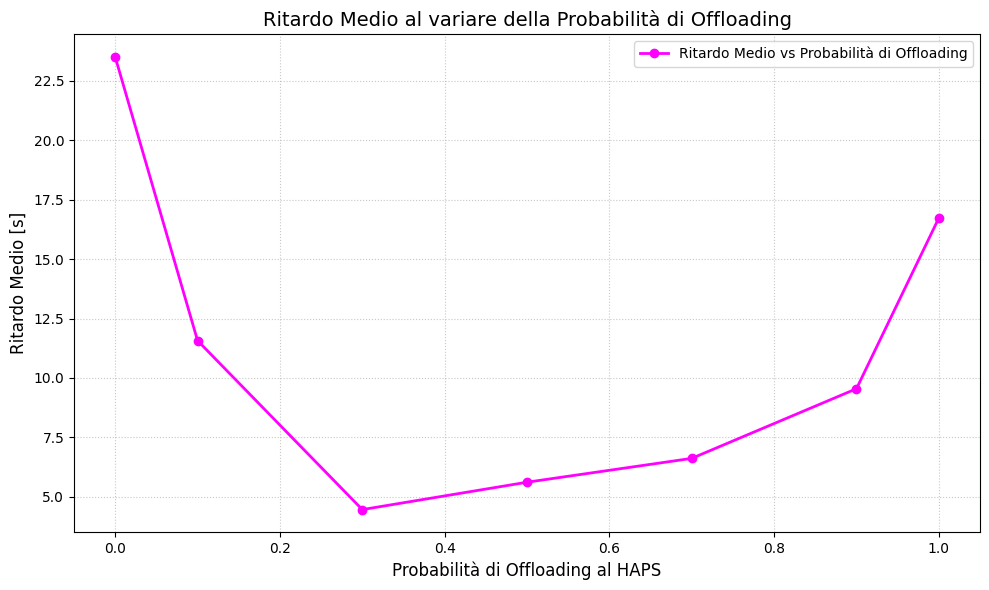

In [269]:
# mostra come cambia il ritardo medio al variare della probabilità di offloading

##DOMANDA, così cambia anche lambda! come faccio ad avere qualcosa di normale?
#Forse quello che dovrei decidere è R_ru
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_node = [5.0, 10.0, 15.0]  # Tassi di arrivo per i tre nodi
f_loc_node = 2.5*1e8 
f_loc_haps = 1*1e9 
probabilities = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
mean_delays = []
num_nodes = len(lambda_node)
for p in probabilities:
    _, _, _, _, _, a_delay, _ = run_multiple_sims_multiple_nodes(
        num_runs=150, 
        tasks_to_complete=500, 
        time_limit=200.0, 
        lambda_rate=lambda_node, 
        f_loc_node=f_loc_node, 
        f_loc_haps=f_loc_haps,
        params_Ks=params,
        alpha=1.0,
        probability_offload=p,
        num_nodes=num_nodes
    )
    mean_delays.append(np.mean(a_delay))
plt.figure(figsize=(10, 6))
plt.plot(probabilities, mean_delays, 'o-', color='magenta', label='Ritardo Medio vs Probabilità di Offloading', linewidth=2)
plt.title("Ritardo Medio al variare della Probabilità di Offloading", fontsize=14)
plt.xlabel("Probabilità di Offloading al HAPS", fontsize=12)
plt.ylabel("Ritardo Medio [s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
